# Q1 · Diagnóstico e Projeção do Índice Bacen
Projeção do índice para H2/2026 e H1/2027 com 3 cenários para os 4.734 casos pendentes e benchmark competitivo contra Nubank, Banco Inter e PicPay.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
print('Dependências carregadas.')

Dependências carregadas.


## 1 · Carregar bases

In [38]:
aba2 = pd.read_csv('../outputs/aba2_limpa.csv')
aba3 = pd.read_csv('../outputs/aba3_limpa.csv')
aba2['RDR_EXTERNAL_CREATE_DTTM'] = pd.to_datetime(aba2['RDR_EXTERNAL_CREATE_DTTM'], format='mixed')

print(f'Aba 2: {aba2.shape[0]:,} registros RDR')
print(f'Status únicos: {aba2.RDR_STATUS_NAME.unique()}')

Aba 2: 6,023 registros RDR
Status únicos: ['Pendente: IF/AC' 'Encerrada: reclamação regulada improcedente'
 'Encerrada: cancelada após resposta da IF/AC'
 'Encerrada: reclamação não regulada'
 'Encerrada: reclamação regulada procedente' 'Encerrada: não conclusiva'
 'Pendente: IF/AC Solicitação de prazo aceita']


## 2 · Parâmetros de Ancoragem e Diagnóstico

**Por que não usar ARIMA/Prophet diretamente sobre a Aba 2?**

A Aba 2 cobre apenas **3 meses** (set–nov/2025) de um único canal regulatório (RDR). Com 357 casos encerrados procedentes, não representa o universo completo do índice Bacen.

O índice oficial Q4/2025 = **29,79** vem da Aba 3 (dados públicos do Bacen) e equivale a **1.862 procedentes** em 62,5M de clientes. Esta é a âncora real do modelo.

**Estratégia adotada:**
1. **Âncora** no índice oficial Q4/2025 (Aba 3)
2. **Decomposição** do volume anual em trimestres com sazonalidade Black Friday (Q4 +20%)
3. **Janela móvel de 12 meses** — o mesmo mecanismo do cálculo oficial do Bacen

In [39]:
# ── Parâmetros âncora Q4/2025 (dados oficiais — Aba 3) ───────────────────────
INDICE_ATUAL    = 29.79          # índice Bacen Q4/2025
CLIENTES_ATUAL  = 62_500_000     # base de clientes Q4/2025
PROC_ANUAL      = round(INDICE_ATUAL * CLIENTES_ATUAL / 1_000_000)  # = 1.862
TAXA_CRESC_AA   = 0.15           # crescimento estimado de clientes a.a.
TAXA_CRESC_TRIM = (1 + TAXA_CRESC_AA) ** (1/4) - 1  # ≈ 3,55% por trimestre

# ── Decomposição trimestral: Q4 tem +20% por sazonalidade Black Friday ────────
BF_MULT  = 1.20
q_base   = round(PROC_ANUAL / (3 + BF_MULT))   # baseline por trimestre
q4_extra = PROC_ANUAL - 3 * q_base              # Q4 absorve o restante (BF)

proc_base_trim = {'Q1': q_base, 'Q2': q_base, 'Q3': q_base, 'Q4': q4_extra}
assert sum(proc_base_trim.values()) == PROC_ANUAL, \
    f"Soma {sum(proc_base_trim.values())} ≠ {PROC_ANUAL}"

print(f'Índice âncora Q4/2025  : {INDICE_ATUAL}')
print(f'Clientes Q4/2025       : {CLIENTES_ATUAL/1e6:.1f}M')
print(f'Procedentes anuais     : {PROC_ANUAL:,}  (= {INDICE_ATUAL} × {CLIENTES_ATUAL/1e6:.1f}M / 1M)')
print(f'Crescimento trimestral : {TAXA_CRESC_TRIM*100:.2f}%  (15% a.a.)')
print()
print('Decomposição trimestral — run-rate + sazonalidade Black Friday:')
for q, v in proc_base_trim.items():
    tag = ' ← Black Friday (+20%)' if q == 'Q4' else ''
    print(f'  {q}: {v:,} procedentes/trimestre{tag}')
print(f'  TOTAL: {sum(proc_base_trim.values()):,} = {PROC_ANUAL:,} ✓')
print()
print('Verificação: índice implícito = '
      f'{PROC_ANUAL / CLIENTES_ATUAL * 1e6:.2f}  (âncora = {INDICE_ATUAL})')

Índice âncora Q4/2025  : 29.79
Clientes Q4/2025       : 62.5M
Procedentes anuais     : 1,862  (= 29.79 × 62.5M / 1M)
Crescimento trimestral : 3.56%  (15% a.a.)

Decomposição trimestral — run-rate + sazonalidade Black Friday:
  Q1: 443 procedentes/trimestre
  Q2: 443 procedentes/trimestre
  Q3: 443 procedentes/trimestre
  Q4: 533 procedentes/trimestre ← Black Friday (+20%)
  TOTAL: 1,862 = 1,862 ✓

Verificação: índice implícito = 29.79  (âncora = 29.79)


## 3 · Cenários para os 4.734 Casos Pendentes

Os 4.734 acionamentos com status **"Pendente: IF/AC"** são o maior risco regulatório. Se julgados procedentes, entram diretamente na janela de 12 meses e elevam o índice.

**Distribuição temporal estimada da resolução:**
- **Q1/2026 (50%)** — prazo regulatório expirado (acionamentos mais antigos, set/out 2025)
- **Q2/2026 (35%)** — segunda leva: prorrogações e recursos em andamento
- **Q3/2026 (15%)** — casos complexos / contestações prolongadas

In [40]:
PENDENTES = 4_734

CENARIOS = {
    'Pessimista (70%)': round(PENDENTES * 0.70),   # 3.314
    'Base (45%)':       round(PENDENTES * 0.45),   # 2.130
    'Otimista (20%)':   round(PENDENTES * 0.20),   #   947
}

# Quando cada lote de pendentes se resolve (pressão de prazo regulatório)
DIST_PENDENTES = {
    'Q1_2026': 0.50,
    'Q2_2026': 0.35,
    'Q3_2026': 0.15,
}

print(f"{'Cenário':<25} {'Total extra':>12}  {'Q1/26':>7} {'Q2/26':>7} {'Q3/26':>7}")
print('-' * 62)
for nome, total_extra in CENARIOS.items():
    q1_e = round(total_extra * DIST_PENDENTES['Q1_2026'])
    q2_e = round(total_extra * DIST_PENDENTES['Q2_2026'])
    q3_e = total_extra - q1_e - q2_e
    print(f'{nome:<25} {total_extra:>12,}  {q1_e:>7,} {q2_e:>7,} {q3_e:>7,}')

print()
print('Impacto máximo no índice se TODOS os pendentes virassem procedentes imediatamente:')
for nome, total_extra in CENARIOS.items():
    idx_impacto = (PROC_ANUAL + total_extra) / CLIENTES_ATUAL * 1_000_000
    print(f'  {nome:<25} → índice = ({PROC_ANUAL:,} + {total_extra:,}) / {CLIENTES_ATUAL/1e6:.1f}M × 1M = {idx_impacto:.2f}')

Cenário                    Total extra    Q1/26   Q2/26   Q3/26
--------------------------------------------------------------
Pessimista (70%)                 3,314    1,657   1,160     497
Base (45%)                       2,130    1,065     746     319
Otimista (20%)                     947      474     331     142

Impacto máximo no índice se TODOS os pendentes virassem procedentes imediatamente:
  Pessimista (70%)          → índice = (1,862 + 3,314) / 62.5M × 1M = 82.82
  Base (45%)                → índice = (1,862 + 2,130) / 62.5M × 1M = 63.87
  Otimista (20%)            → índice = (1,862 + 947) / 62.5M × 1M = 44.94


## 4 · Modelo de Projeção — Janela Móvel de 12 Meses

O Bacen calcula o índice sobre uma **janela deslizante de 12 meses**. A cada trimestre, um novo bloco de 3 meses entra e o bloco correspondente de 1 ano atrás sai.

```
rolling[t] = rolling[t-4] − inflow[t-4] + inflow[t]

inflow[t]  = run-rate trimestral base (Q1–Q3: 443/trim · Q4 Black Friday: 533/trim)
           + extras dos pendentes convertidos (apenas Q1–Q3/2026)
```

Este modelo captura corretamente:
- **Choque temporário** (Q1–Q3/2026): os pendentes se convertem e elevam a janela
- **Recuperação** (Q1/2027+): o choque de Q1/2026 sai da janela → índice cai
- **Diluição pelo crescimento**: base de +3,55%/trimestre reduz o índice progressivamente
- **Sazonalidade**: Q4 tem +20% de volume (Black Friday)

In [41]:
import pandas as pd
import numpy as np

# ── Inflow histórico 2025 (inicializa a janela móvel 12 meses) ───────────────
inflow_2025 = {
    'Q1/2025': proc_base_trim['Q1'],   # 443
    'Q2/2025': proc_base_trim['Q2'],   # 443
    'Q3/2025': proc_base_trim['Q3'],   # 443
    'Q4/2025': proc_base_trim['Q4'],   # 533  ← Black Friday 2025
}
assert sum(inflow_2025.values()) == PROC_ANUAL

# Run-rate base por trimestre projetado (Q4/2026 ainda tem BF)
inflow_base_proj = {
    'Q1/2026': proc_base_trim['Q1'],
    'Q2/2026': proc_base_trim['Q2'],
    'Q3/2026': proc_base_trim['Q3'],
    'Q4/2026': proc_base_trim['Q4'],   # Black Friday 2026
    'Q1/2027': proc_base_trim['Q1'],
    'Q2/2027': proc_base_trim['Q2'],
}

periodos = ['Q1/2026', 'Q2/2026', 'Q3/2026', 'Q4/2026', 'Q1/2027', 'Q2/2027']
datas_fim = {
    'Q1/2026': pd.Timestamp('2026-03-31'),
    'Q2/2026': pd.Timestamp('2026-06-30'),
    'Q3/2026': pd.Timestamp('2026-09-30'),
    'Q4/2026': pd.Timestamp('2026-12-31'),
    'Q1/2027': pd.Timestamp('2027-03-31'),
    'Q2/2027': pd.Timestamp('2027-06-30'),
}

# ── Projeção por cenário ──────────────────────────────────────────────────────
resultados = {}

for nome_cen, total_extra in CENARIOS.items():
    chave = nome_cen.split()[0].lower()

    q1_e = round(total_extra * DIST_PENDENTES['Q1_2026'])
    q2_e = round(total_extra * DIST_PENDENTES['Q2_2026'])
    q3_e = total_extra - q1_e - q2_e    # absorve arredondamento
    extras = {
        'Q1/2026': q1_e, 'Q2/2026': q2_e, 'Q3/2026': q3_e,
        'Q4/2026': 0,    'Q1/2027': 0,    'Q2/2027': 0,
    }

    inflow_hist = dict(inflow_2025)   # rastreia inflow de cada período
    rolling     = PROC_ANUAL
    clientes    = CLIENTES_ATUAL
    rows        = []

    for t in periodos:
        inflow_t = inflow_base_proj[t] + extras[t]
        # Chave do período 4 trimestres atrás (sai da janela de 12 meses)
        q_str, yr_str = t.split('/')
        prev_key = f'{q_str}/{int(yr_str) - 1}'
        sai      = inflow_hist[prev_key]

        rolling  = rolling - sai + inflow_t
        clientes = clientes * (1 + TAXA_CRESC_TRIM)
        indice   = rolling / clientes * 1_000_000

        inflow_hist[t] = inflow_t   # guarda para o ano seguinte usar no "sai"
        rows.append({
            'periodo': t, 'ds': datas_fim[t],
            'inflow': inflow_t, 'extras_pendentes': extras[t],
            'proc_rolling12m': rolling,
            'clientes': clientes, 'indice': indice,
        })

    resultados[chave] = pd.DataFrame(rows)

# ── DataFrame unificado ───────────────────────────────────────────────────────
proj = resultados['pessimista'][['periodo', 'ds', 'clientes']].copy()
for chave in ['pessimista', 'base', 'otimista']:
    df_c = resultados[chave]
    proj[f'indice_{chave}']          = df_c['indice'].values
    proj[f'proc_rolling12m_{chave}'] = df_c['proc_rolling12m'].values
    proj[f'extras_{chave}']          = df_c['extras_pendentes'].values

# ── Resultado ─────────────────────────────────────────────────────────────────
print('Projeção trimestral — Índice Bacen por cenário:')
print(f'  Âncora Q4/2025: {INDICE_ATUAL}')
print()
print(f"  {'Trimestre':<10} {'Pessimista':>12} {'Base':>12} {'Otimista':>12}")
print('  ' + '-' * 50)
for _, row in proj.iterrows():
    print(f"  {row['periodo']:<10} {row['indice_pessimista']:>12.2f} "
          f"{row['indice_base']:>12.2f} {row['indice_otimista']:>12.2f}")

Projeção trimestral — Índice Bacen por cenário:
  Âncora Q4/2025: 29.79

  Trimestre    Pessimista         Base     Otimista
  --------------------------------------------------
  Q1/2026           54.37        45.22        36.09
  Q2/2026           69.81        54.80        39.79
  Q3/2026           74.57        57.52        40.47
  Q4/2026           72.01        55.54        39.08
  Q1/2027           47.28        39.33        31.37
  Q2/2027           30.61        28.30        26.00


## 5 · Validar projeção e tabela final de índices

In [ ]:
colunas_saida = [
    'ds',
    'procedentes_pessimista',
    'procedentes_base',
    'procedentes_otimista',
    'indice_pessimista',
    'indice_base',
    'indice_otimista',
]

print(proj[colunas_saida].to_string(index=False))

## 6 · Benchmark competitivo — Aba 3

In [43]:
print('Concorrentes (Q4/2025):')
print(aba3.to_string(index=False))

Concorrentes (Q4/2025):
Instituição Financeira (Conglomerado)  Índice Bacen (Q1 2025)  Índice Bacen (Q2 2025)  Índice Bacen (Q3 2025)  Índice Bacen (Q4 2025)  Base Total de Clientes (Milhões - Ref. Q4 2025)  Vol. Reclamações Procedentes (Ref. Q4 2025)
                  PagBank (PagSeguro)                   79.26                    75.1                    71.0                    68.5                                             34.5                                         2363
                              C6 Bank                   67.18                    65.2                    68.1                    64.3                                             32.1                                         2064
                               PicPay                   28.50                    30.1                    33.4                    35.2                                             36.2                                         1274
                         Mercado Pago                   31.18   

## 7 · Gráfico de projeção por cenários com benchmark

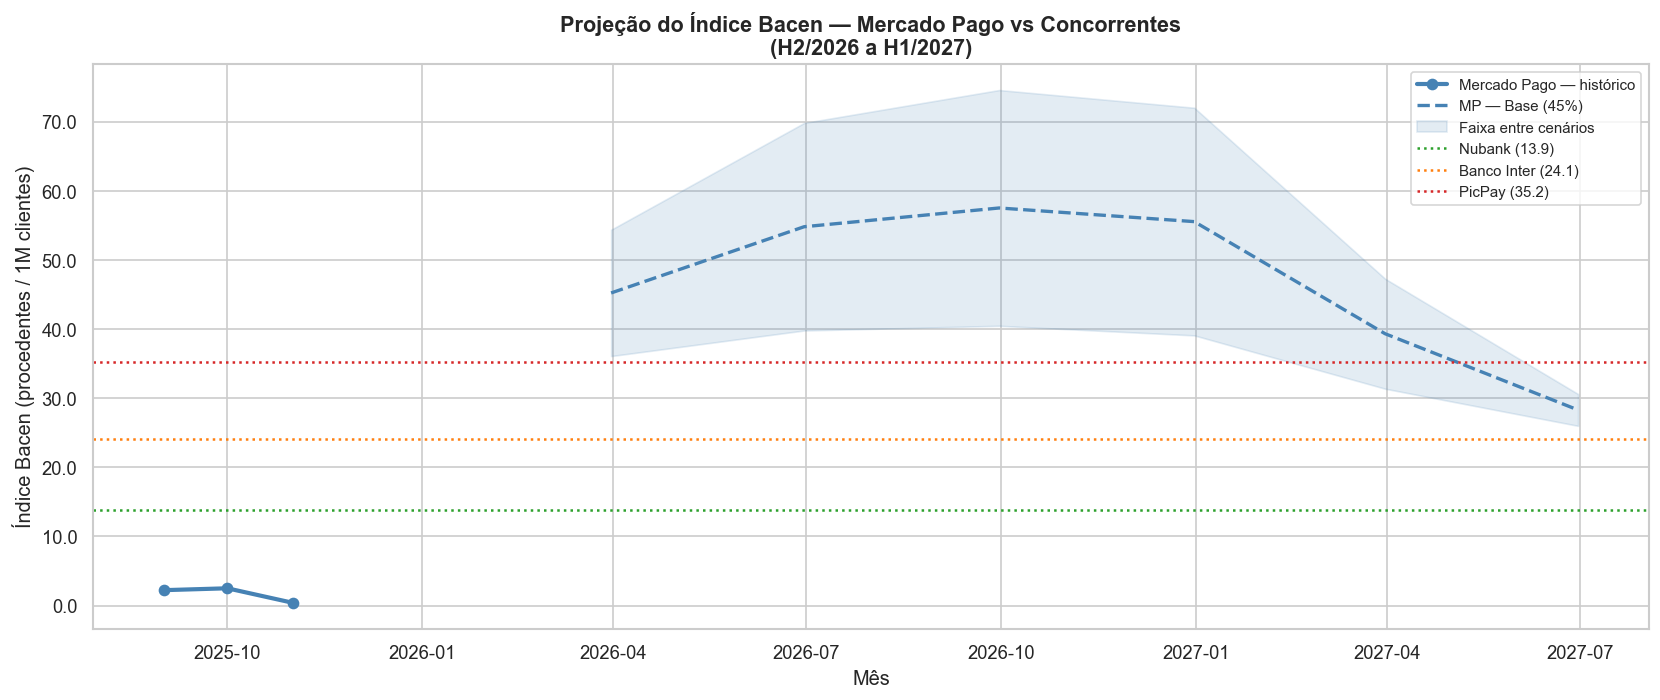

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuração visual
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Benchmarks
BENCH = {
    'Nubank': 13.90,
    'Banco Inter': 24.10,
    'PicPay': 35.20,
}

# Criação da figura
fig, ax = plt.subplots(figsize=(14, 6))

# Histórico
ax.plot(
    serie['ds'],
    serie['indice'],
    'o-',
    color='steelblue',
    lw=2.5,
    label='Mercado Pago — histórico',
    zorder=5
)

# Projeção — cenário base
col_base = [c for c in proj.columns if 'base' in c][0]

ax.plot(
    proj['ds'],
    proj[col_base],
    '--',
    color='steelblue',
    lw=2,
    label='MP — Base (45%)'
)

# Faixa entre cenários (pessimista vs otimista)
faixa_inferior = np.minimum(proj['indice_pessimista'], proj['indice_otimista'])
faixa_superior = np.maximum(proj['indice_pessimista'], proj['indice_otimista'])

ax.fill_between(
    proj['ds'],
    faixa_inferior,
    faixa_superior,
    alpha=0.15,
    color='steelblue',
    label='Faixa entre cenários'
)

# Benchmarks
cores_bench = {
    'Nubank': '#2ca02c',
    'Banco Inter': '#ff7f0e',
    'PicPay': '#d62728'
}

for inst, idx in BENCH.items():
    ax.axhline(
        idx,
        linestyle=':',
        color=cores_bench[inst],
        lw=1.5,
        label=f'{inst} ({idx})'
    )

# Título corrigido (com quebra de linha)
ax.set_title(
    'Projeção do Índice Bacen — Mercado Pago vs Concorrentes\n(H2/2026 a H1/2027)',
    fontweight='bold',
    fontsize=13
)

# Labels
ax.set_xlabel('Mês')
ax.set_ylabel('Índice Bacen (procedentes / 1M clientes)')

# Legenda
ax.legend(fontsize=9)

# Formatação eixo Y
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

# Ajuste de layout
plt.tight_layout()

# Salvar figura
plt.savefig('../outputs/01_projecao_indice.png', bbox_inches='tight')

# Mostrar gráfico
plt.show()

## 8 · Trimestre de ultrapassagem (janela alvo: H2/2026 e H1/2027)

In [45]:
proj['trimestre'] = proj['ds'].dt.to_period('Q').astype(str)

janela = proj[(proj['ds'] >= '2026-07-01') & (proj['ds'] <= '2027-06-30')].copy()

print('Quando o MP supera cada concorrente (cenário base) na janela H2/2026-H1/2027?')
print()
for inst, idx_conc in BENCH.items():
    ultrapassa = janela[janela[col_base] < idx_conc]
    if len(ultrapassa):
        print(f'  {inst} (índice {idx_conc}): MP supera em {ultrapassa.iloc[0].trimestre}')
    else:
        print(f'  {inst}: MP ainda não supera na janela analisada')

Quando o MP supera cada concorrente (cenário base) na janela H2/2026-H1/2027?

  Nubank: MP ainda não supera na janela analisada
  Banco Inter: MP ainda não supera na janela analisada
  PicPay (índice 35.2): MP supera em 2027Q2


## 9 · Exportar projeção

In [ ]:
proj.to_csv('../outputs/01_projecao_mp.csv', index=False)
print('Projeção exportada para ../outputs/01_projecao_mp.csv')

Projeção exportada para ../outputs/01_projecao_mp.csv
